In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import pycbc
from pycbc.waveform import get_td_waveform

import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline

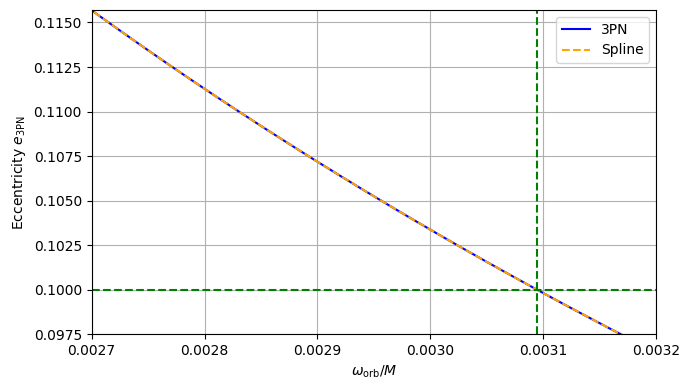

In [2]:
gamma_E = 0.5772156649015329

q = 1.0
eta = q / (1 + q)**2

e_ref = 0.1
f_gw_ref = 10.0
M_sun_sec = 4.92549095e-6
M_total = 20.0
M_sec = M_total * M_sun_sec

def g_function_3pn(f_dimless):
    term_0pn = 1.0
    term_1pn = (-2833/2016 + 197/72 * eta) * f_dimless**(2/3)
    term_1p5pn = -377/144 * np.pi * f_dimless
    term_2pn = (77006005/24385536 - 1143767/145152 * eta +
                43807/10368 * eta**2) * f_dimless**(4/3)
    term_2p5pn = (9901567/1451520 - 202589/362880 * eta) * np.pi * f_dimless**(5/3)
    bracket = (-33320661414619/386266890240
               + 3317/252 * gamma_E
               + 180721/41472 * np.pi**2
               + (161339510737/8778792960 + 3977/2304 * np.pi**2) * eta
               - 359037739/20901888 * eta**2
               + 10647791/2239488 * eta**3
               - 87419/3780 * np.log(2)
               + 26001/1120 * np.log(3)
               + 3317/504 * np.log(16 * f_dimless**(2/3)))
    term_3pn = bracket * f_dimless**2
    return term_0pn + term_1pn + term_1p5pn + term_2pn + term_2p5pn + term_3pn

def eccentricity_track(f_gw_array_Hz):
    f_ref_dim = f_gw_ref * M_sec
    g_ref = g_function_3pn(f_ref_dim)

    f_dim_array = f_gw_array_Hz * M_sec
    g_array = g_function_3pn(f_dim_array)

    e_array = e_ref * (f_gw_ref / f_gw_array_Hz)**(19/18) * (g_array / g_ref)
    omega_orb_array = np.pi * f_gw_array_Hz * M_sec
    return omega_orb_array, e_array

f_gw_array = np.linspace(5, 12, 200)
omega_orb, ecc = eccentricity_track(f_gw_array)

ecc_spline = interpolate.CubicSpline(omega_orb, ecc)

omega_dense = np.linspace(omega_orb.min(), omega_orb.max(), 1000)

plt.figure(figsize=(7,4))
plt.plot(omega_orb, ecc, 'b-', label="3PN")
plt.plot(omega_dense, ecc_spline(omega_dense), 'orange', ls='--', label="Spline")

plt.axhline(e_ref, color='green', ls='--')
plt.axvline(np.pi * f_gw_ref * M_sec, color='green', ls='--')

plt.xlabel(r'$\omega_{\rm orb} / M$')
plt.ylabel(r'Eccentricity $e_{3\rm PN}$')
plt.legend()
plt.grid(True)
plt.ylim(0.0975, 0.1157)
plt.xlim(0.0027, 0.0032)
plt.tight_layout()
plt.show()

In [3]:
mask = (omega_orb >= 0.0027) & (omega_orb <= 0.0032)
omega_orb_masked = omega_orb[mask]

ecc_masked = ecc[mask]

In [4]:
f_low_arr = omega_orb_masked / (M_sec * np.pi)

In [5]:
f_array = np.linspace(9.5, 10, 20)

ref_m1 = 10
ref_m2 = 10
approximant = 'teobresums'

hp_ref, hc_ref = get_td_waveform(approximant=approximant,
                                mass1=ref_m1, mass2=ref_m2,
                                ecc=e_ref,
                                lambda1=0, lambda2=0,
                                f_lower=f_gw_ref,
                                delta_t=1.0/4096)

ref_signal = hp_ref - 1j*hc_ref
ref_times = list(ref_signal.sample_times)
dt = np.abs(ref_times[0] - ref_times[1])

def generate_waveform(f):
    omega = f * np.pi * M_sec
    eccentricity = ecc_spline(omega)
    
    hp_test, hc_test = get_td_waveform(approximant=approximant,
                                    mass1=ref_m1, mass2=ref_m2,
                                    ecc=eccentricity,
                                    lambda1=0, lambda2=0,
                                    f_lower=f,
                                    delta_t=1.0/4096)
    
    test_signal = hp_test - 1j*hc_test
    test_signal = test_signal.time_slice(ref_signal.sample_times[0], 0)

    return test_signal

def l2_error(ref_signal, test_signal):
    ref_times = np.asarray(ref_signal.sample_times)
    ref_data  = np.asarray(ref_signal.data)

    test_times = np.asarray(test_signal.sample_times)
    test_data  = np.asarray(test_signal.data)

    interp_real = interp1d(test_times, test_data.real, kind='cubic',
                           bounds_error=False, fill_value=0)
    interp_imag = interp1d(test_times, test_data.imag, kind='cubic',
                           bounds_error=False, fill_value=0)

    test_reco_real = interp_real(ref_times)
    test_reco_imag = interp_imag(ref_times)
    test_reco = test_reco_real + 1j * test_reco_imag  

    dt = np.abs(ref_times[0] - ref_times[1])

    inner = np.vdot(ref_data, test_reco) 
    phase = np.angle(inner)
    tdata_aligned = test_reco * np.exp(-1j * phase)

    num = 0.5 * np.real(np.sum((ref_data - tdata_aligned) * np.conj(ref_data - tdata_aligned)) * dt)
    den = np.real(np.sum(ref_data * np.conj(ref_data)) * dt)

    return num / den

error_list = []

for i in f_array:
    test_signal = generate_waveform(i)
    error = l2_error(ref_signal=ref_signal, test_signal=test_signal)
    error_list.append(error)

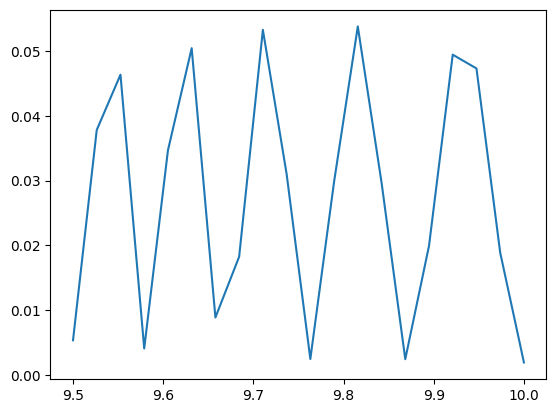

In [6]:
plt.plot(f_array, error_list)

In [7]:
error_spline = CubicSpline(f_array * np.pi * M_sec, error_list)

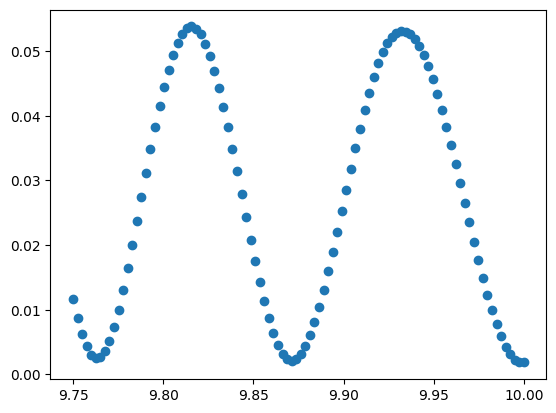

In [8]:
dense_f_error = np.linspace(9.75, 10, 100)
densed_error = error_spline(dense_f_error * np.pi * M_sec)

plt.scatter(dense_f_error, densed_error)

In [9]:
mask = (dense_f_error >= 9.95) & (dense_f_error <= 10.0)
x_min = dense_f_error[mask][np.argmin(densed_error[mask])]
y_min = np.min(densed_error[mask])

print(f"x_min = {x_min}, y_min = {y_min}")

mask = (dense_f_error >= 9.85) & (dense_f_error <= 9.9)
x_min = dense_f_error[mask][np.argmin(densed_error[mask])]
y_min = np.min(densed_error[mask])

print(f"x_min = {x_min}, y_min = {y_min}")

x_min = 9.997474747474747, y_min = 0.0018512452644718997
x_min = 9.871212121212121, y_min = 0.002104614026502191


## Decomposing Eccentric Harmonics

In [11]:
f_min = x_min
f_max = 10.0

freq_grid = np.linspace(f_min, f_max, 50)
omega_grid = freq_grid * np.pi * M_sec
ecc_grid = ecc_spline(omega_grid)

In [ ]:
X = np.zeros((len(freq_grid), len(ref_signal.sample_times)), dtype=complex)

ref_times = np.asarray(ref_signal.sample_times)
ref_data  = np.asarray(ref_signal.data)

for j, f in enumerate(freq_grid):
    x = generate_waveform(f)
    x_times = np.asarray(x.sample_times)
    x_data  = np.asarray(x.data)

    interp_real = interp1d(x_times, x_data.real, kind='cubic',
                           bounds_error=False, fill_value=0)
    interp_imag = interp1d(x_times, x_data.imag, kind='cubic',
                           bounds_error=False, fill_value=0)

    x_reco_real = interp_real(ref_times)
    x_reco_imag = interp_imag(ref_times)
    x_reco = x_reco_real + 1j * x_reco_imag  

    inner = np.vdot(ref_data, x_reco) 
    phase = np.angle(inner)
    xdata_aligned = x_reco * np.exp(-1j * phase)

    X[j, :] = xdata_aligned

In [13]:
U, s, Vt = np.linalg.svd(X, full_matrices=False)

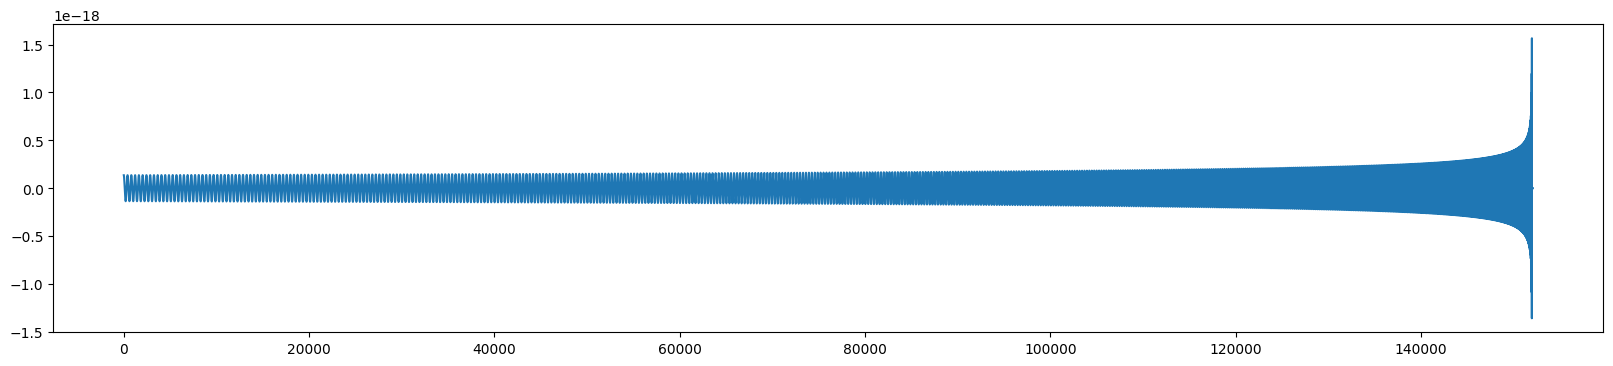

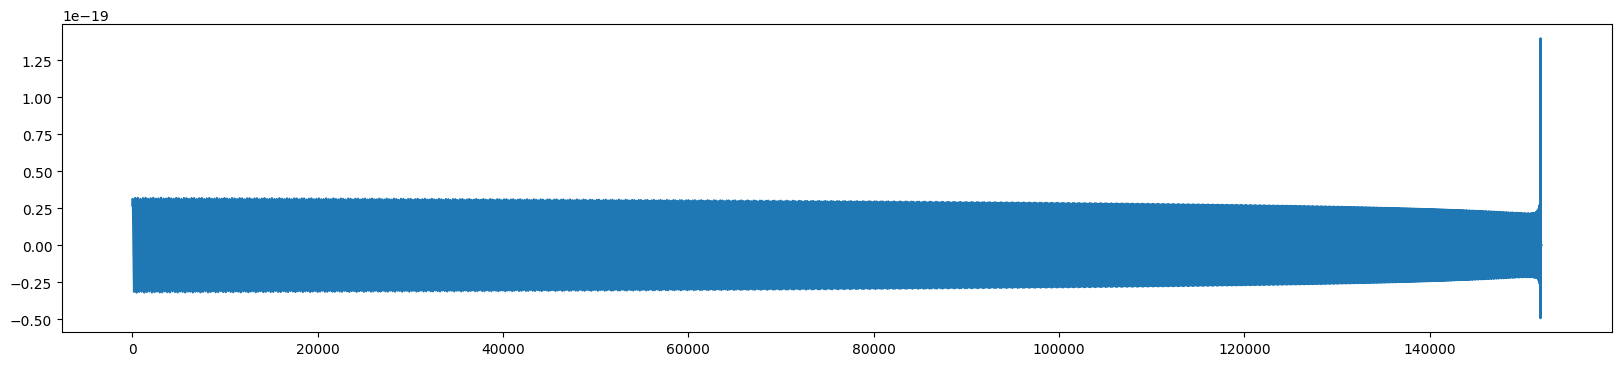

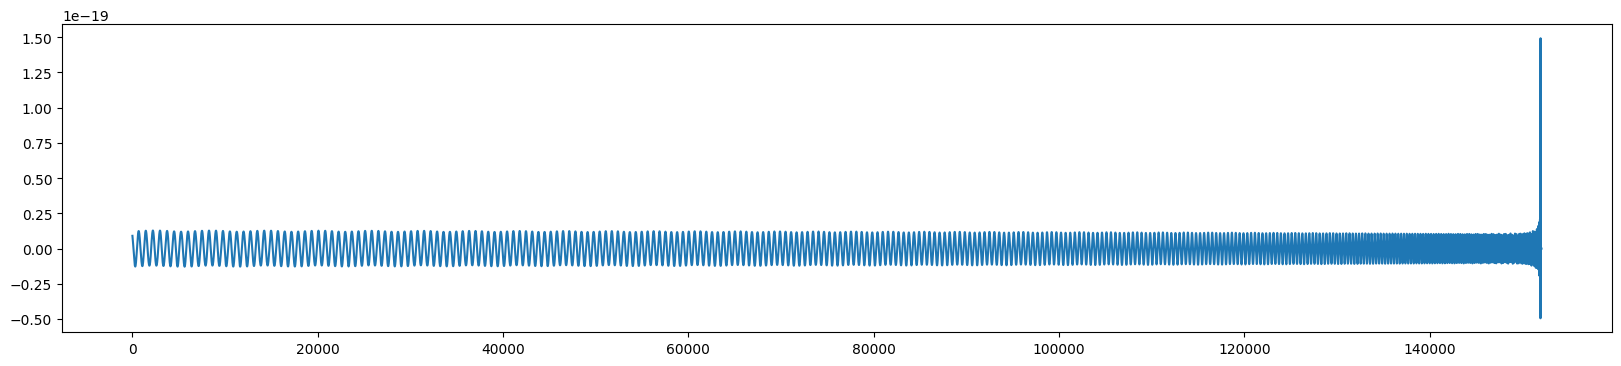

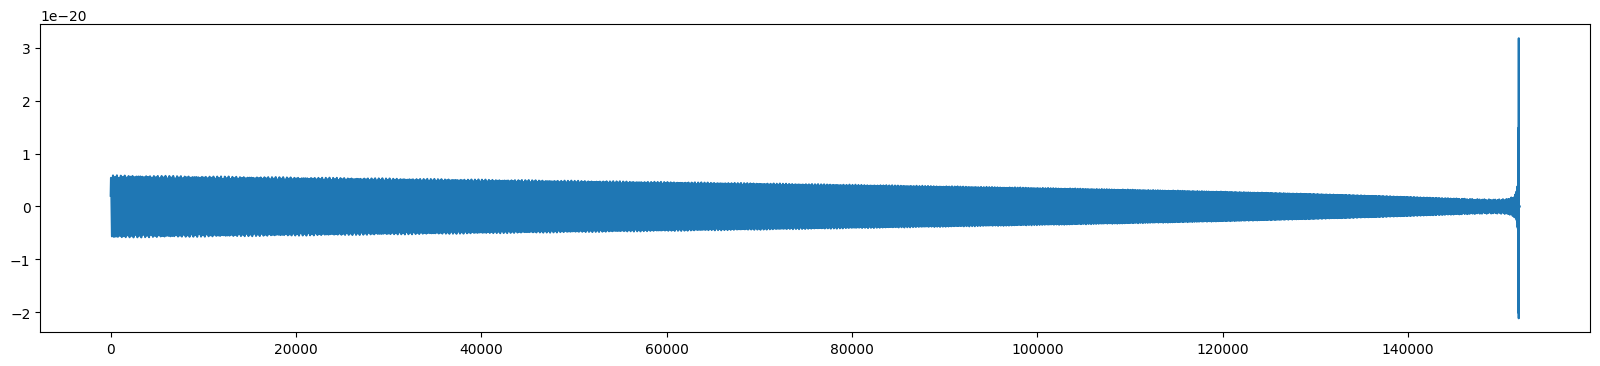

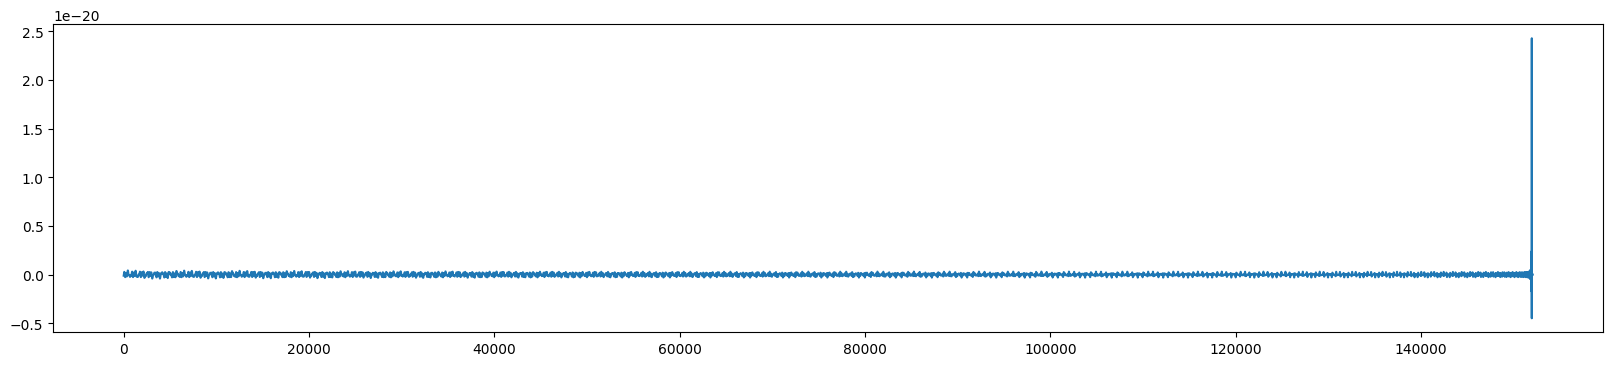

In [19]:
for i in range(5):
    plt.figure(figsize=(20,4))
    plt.plot(s[i] * Vt[i].real)
    plt.show()